In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping



In [114]:
ml_df = pd.read_csv("wfp_uganda_food_prices_ml_ready.csv")
ml_df.shape

(20872, 21)

In [115]:
ml_df.head()

,date,year,month,quarter,admin1,admin2,market,market_id,latitude,longitude,...,commodity,commodity_id,unit,price,previous_price,price_change,price_pct_change,price_3_month_avg,price_6_month_avg,next_month_price
0,2011-09-15,2011,9,3,Kyankwanzi,Kiboga,Kiboga,257,0.92,31.77,...,Beans,50,KG,1500.0,1667.0,-167.0,-0.100180,1555.666667,1794.500000,1900.0
1,2011-10-15,2011,10,4,Kyankwanzi,Kiboga,Kiboga,257,0.92,31.77,...,Beans,50,KG,1900.0,1500.0,400.0,0.266667,1689.000000,1786.166667,1632.0
2,2011-11-15,2011,11,4,Kyankwanzi,Kiboga,Kiboga,257,0.92,31.77,...,Beans,50,KG,1632.0,1900.0,-268.0,-0.141053,1677.333333,1699.833333,1425.0
3,2012-01-15,2012,1,1,Kyankwanzi,Kiboga,Kiboga,257,0.92,31.77,...,Beans,50,KG,1425.0,1632.0,-207.0,-0.126838,1652.333333,1604.000000,1450.0
4,2012-02-15,2012,2,1,Kyankwanzi,Kiboga,Kiboga,257,0.92,31.77,...,Beans,50,KG,1450.0,1425.0,25.0,0.017544,1502.333333,1595.666667,1609.0


The dataset was sorted by date because this is a time-related prediction problem. The model will be trained on older records and tested on newer records to better simulate real-world forecasting.

In [116]:
#making sure that the date is in date time format
ml_df = ml_df.sort_values("date").copy()

ml_df[["date", "market", "commodity", "price", "next_month_price"]].head()

,date,market,commodity,price,next_month_price
16429,2008-12-15,Owino,Plantains,412.50,395.00
9477,2008-12-15,Owino,Cassava flour,775.00,776.92
9478,2009-01-15,Owino,Cassava flour,776.92,800.00
16430,2009-01-15,Owino,Plantains,395.00,386.00
16431,2009-02-15,Owino,Plantains,386.00,619.23


The target variable is `next_month_price`, which represents the next recorded retail price for the same commodity in the same market. This makes the project a regression task.

In [117]:
# Define the target value
target = "next_month_price"

y = ml_df[target]

y.head()

,next_month_price
16429,395.00
9477,776.92
9478,800.00
16430,386.00
16431,619.23


In [118]:
# select input features
features = [
    "year",
    "month",
    "quarter",
    "admin1",
    "admin2",
    "market",
    "latitude",
    "longitude",
    "category",
    "commodity",
    "unit",
    "price",
    "previous_price",
    "price_change",
    "price_pct_change",
    "price_3_month_avg",
    "price_6_month_avg"
]

X = ml_df[features].copy()

X.head()

,year,month,quarter,admin1,admin2,market,latitude,longitude,category,commodity,unit,price,previous_price,price_change,price_pct_change,price_3_month_avg,price_6_month_avg
16429,2008,12,4,Kampala,Central Kampala,Owino,0.32,32.57,vegetables and fruits,Plantains,KG,412.50,407.27,5.23,0.012842,414.923333,362.021667
9477,2008,12,4,Kampala,Central Kampala,Owino,0.32,32.57,cereals and tubers,Cassava flour,KG,775.00,787.50,-12.50,-0.015873,757.500000,738.720000
9478,2009,1,1,Kampala,Central Kampala,Owino,0.32,32.57,cereals and tubers,Cassava flour,KG,776.92,775.00,1.92,0.002477,779.806667,751.540000
16430,2009,1,1,Kampala,Central Kampala,Owino,0.32,32.57,vegetables and fruits,Plantains,KG,395.00,412.50,-17.50,-0.042424,404.923333,383.480000
16431,2009,2,1,Kampala,Central Kampala,Owino,0.32,32.57,vegetables and fruits,Plantains,KG,386.00,395.00,-9.00,-0.022785,397.833333,396.146667


In [119]:
# separate numeric and categorical columns
numeric_features = [
    "year",
    "month",
    "quarter",
    "latitude",
    "longitude",
    "price",
    "previous_price",
    "price_change",
    "price_pct_change",
    "price_3_month_avg",
    "price_6_month_avg"
]

categorical_features = [
    "admin1",
    "admin2",
    "market",
    "category",
    "commodity",
    "unit"
]
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['year', 'month', 'quarter', 'latitude', 'longitude', 'price', 'previous_price', 'price_change', 'price_pct_change', 'price_3_month_avg', 'price_6_month_avg']
Categorical features: ['admin1', 'admin2', 'market', 'category', 'commodity', 'unit']


In [120]:
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['year', 'month', 'quarter', 'latitude', 'longitude', 'price', 'previous_price', 'price_change', 'price_pct_change', 'price_3_month_avg', 'price_6_month_avg']
Categorical features: ['admin1', 'admin2', 'market', 'category', 'commodity', 'unit']


A time-based train-test split was used instead of a random split. The model was trained on earlier records and tested on later records, which better reflects real-world food price prediction.

In [121]:
# create a time based train test split
split_index = int(len(ml_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (16697, 17)
X_test: (4175, 17)


In [122]:
# check the date ranges for train and test data
train_dates = ml_df.iloc[:split_index]["date"]
test_dates = ml_df.iloc[split_index:]["date"]

print("Training date range:", train_dates.min(), "to", train_dates.max())
print("Testing date range:", test_dates.min(), "to", test_dates.max())

Training date range: 2008-12-15 to 2024-12-15
Testing date range: 2024-12-15 to 2026-05-15


In [123]:
# create preprocessing timeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [124]:
# Test the processor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (16697, 152)
Processed testing shape: (4175, 152)


The number of columns will increase because categorical variables are converted into numeric dummy variables.

In [125]:
# create a simple baseline model to predict that next month’s price will be the same as the current price.
baseline_predictions = X_test["price"]

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R2:", baseline_r2)


Baseline MAE: 557.6970850299401
Baseline RMSE: 1975.4162958811346
Baseline R2: 0.8585578687010419


A baseline model was created by assuming that next month’s price will be equal to the current price. The machine learning models should perform better than this baseline to be considered useful.

# Classical Machine Learning Model
We shall use Random Forest Regressor because it works well with mixed data and can capture non-linear price patterns.

In [126]:
# Random Forest pipeline
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=20,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [127]:
# Train the model
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['year', 'month', 'quarter',
                                                   'latitude', 'longitude',
                                                   'price', 'previous_price',
                                                   'price_change',
                                                   'price_pct_change',
                                                   'price_3_month_avg',
                                                   'price_6_month_avg']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['admin1', 'admin2', 'market',
                                                   'category', 'commodity',
                                                   'unit'])])),
                ('model',
                 RandomForestRegressor(max_depth=20, n_jobs=-1,
                                       random_state=42))])

In [128]:
# make predictions

rf_predictions = rf_model.predict(X_test)

rf_predictions[:10]

array([ 1423.36216288,  1363.47052858,  7506.22488978, 27411.58      ,
        1396.70422522,  1832.46920215,  4201.56662895,  1901.20861417,
        1876.34641004,  3361.54850195])

In [129]:
# Evaluate the random forest model
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)


Random Forest MAE: 533.1968325450372
Random Forest RMSE: 1697.6972368668853
Random Forest R2: 0.8955323052843417


In [130]:
# compare baseline vs random forest
model_comparison = pd.DataFrame({
    "Model": ["Baseline", "Random Forest"],
    "MAE": [baseline_mae, rf_mae],
    "RMSE": [baseline_rmse, rf_rmse],
    "R2": [baseline_r2, rf_r2]
})

model_comparison

,Model,MAE,RMSE,R2
0,Baseline,557.697085,1975.416296,0.858558
1,Random Forest,533.196833,1697.697237,0.895532


The Random Forest model was compared against the baseline model. The baseline assumes that next month’s price is equal to the current month’s price. A useful machine learning model should have a lower MAE and RMSE, and a higher R² value than the baseline.

The Random Forest model performed better than the baseline model.


This shows that the Random Forest model reduced prediction error and explained more variation in next month retail food prices. The model improved on the baseline, especially in RMSE and R², meaning it handled larger prediction errors better than the simple assumption that next month’s price equals the current price.

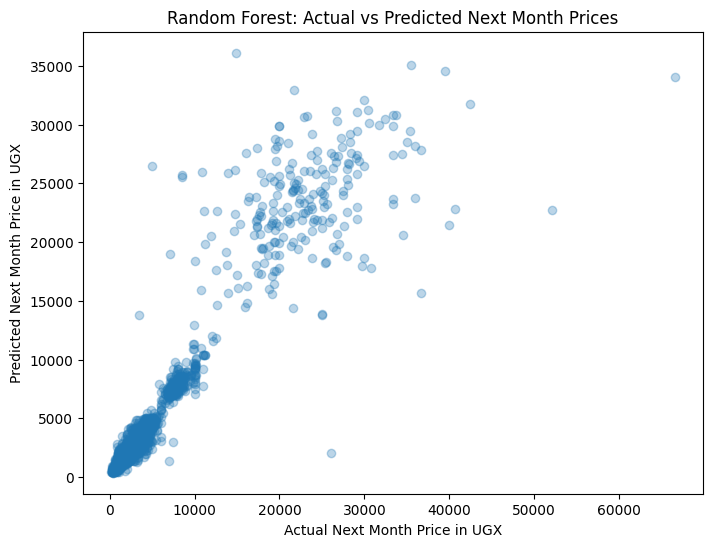

In [131]:
#Visualize actual vs predicted prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_predictions, alpha=0.3)
plt.title("Random Forest: Actual vs Predicted Next Month Prices")
plt.xlabel("Actual Next Month Price in UGX")
plt.ylabel("Predicted Next Month Price in UGX")
plt.show()

The scatter plot compares actual next month prices with the prices predicted by the Random Forest model. Points closer to a diagonal pattern indicate better predictions. Large deviations from the pattern suggest prediction errors, possibly caused by sudden price changes or outliers.

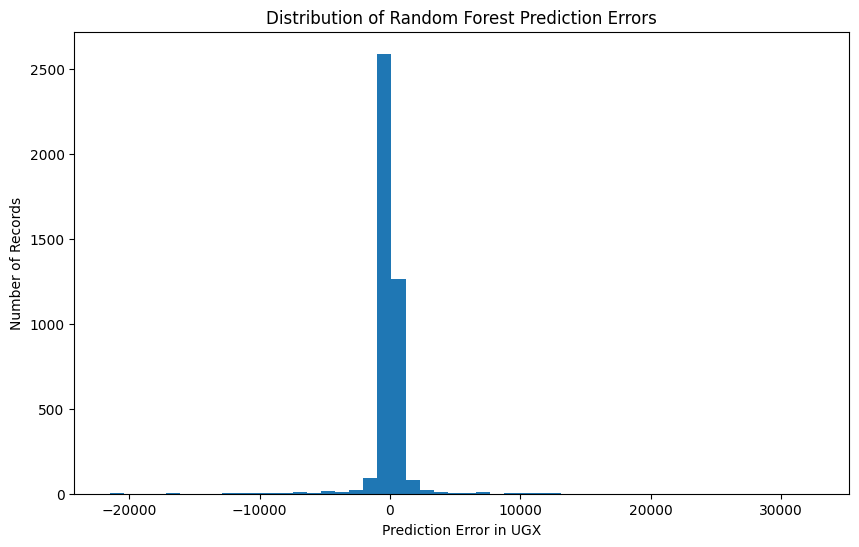

In [132]:
# Check Prediction Errors
errors = y_test - rf_predictions

plt.figure(figsize=(10, 6))
plt.hist(errors, bins=50)
plt.title("Distribution of Random Forest Prediction Errors")
plt.xlabel("Prediction Error in UGX")
plt.ylabel("Number of Records")
plt.show()

The error distribution shows how far the model predictions are from the actual next month prices. If most errors are close to zero, the model is performing well. Wider spread indicates larger prediction errors.

In [133]:
# create a results dataframe to inspect actual predictions
results_df = X_test.copy()
results_df["actual_next_month_price"] = y_test
results_df["predicted_next_month_price"] = rf_predictions
results_df["prediction_error"] = results_df["actual_next_month_price"] - results_df["predicted_next_month_price"]

results_df[[
    "year",
    "month",
    "market",
    "commodity",
    "price",
    "actual_next_month_price",
    "predicted_next_month_price",
    "prediction_error"
]].head(20)

,year,month,market,commodity,price,actual_next_month_price,predicted_next_month_price,prediction_error
18960,2024,12,Kyaka II (refugee settlement),Milk (fresh),1500.0,1733.0,1423.362163,309.637837
19660,2024,12,Kyaka II (refugee settlement),Leafy vegetables,2000.0,2000.0,1363.470529,636.529471
14533,2024,12,Lira,Oil (vegetable),7500.0,6688.0,7506.224890,-818.224890
16983,2024,12,Rwamwanja (refugee settlement),Fish (dry),27328.0,33333.0,27411.580000,5921.420000
4057,2024,12,Soroti,Sorghum,1300.0,1267.0,1396.704225,-129.704225
19714,2024,12,Lobule (refugee settlement),Leafy vegetables,1853.0,2105.0,1832.469202,272.530798
358,2024,12,Iganga,Beans,4250.0,4000.0,4201.566629,-201.566629
18109,2024,12,Adjumani (refugee settlement),Salt,1920.0,1960.0,1901.208614,58.791386
4201,2024,12,Arua,Sorghum,1900.0,1500.0,1876.346410,-376.346410
1299,2024,12,Namalu,Beans,3700.0,4067.0,3361.548502,705.451498


In [134]:
#save model results
results_df.to_csv("/content/random_forest_predictions.csv", index=False)

In [135]:
from google.colab import files
files.download("random_forest_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##  Summary: Classical Machine Learning Model

In this step, a Random Forest Regressor was trained to predict the next month retail food price in Ugandan markets.

The model used numerical features such as current price, previous price, price change, moving averages, latitude, longitude, year, month and quarter. It also used categorical features such as market, commodity, category, district, region and unit.

The model was evaluated using MAE, RMSE and R², and its performance was compared against a baseline model that assumed next month’s price would be equal to the current month’s price.

#  Neural Network Model
The preprocessing output may be a sparse matrix because of one-hot encoding. Neural networks need numeric arrays.

In [136]:
# convert processed data to dense format. 

X_train_nn = X_train_processed
X_test_nn = X_test_processed

if hasattr(X_train_nn, "toarray"):
    X_train_nn = X_train_nn.toarray()

if hasattr(X_test_nn, "toarray"):
    X_test_nn = X_test_nn.toarray()

print("Neural network training shape:", X_train_nn.shape)
print("Neural network testing shape:", X_test_nn.shape)

Neural network training shape: (16697, 152)
Neural network testing shape: (4175, 152)


In [137]:
# scale the target variable so that the neural network can perfom better.
target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(np.array(y_train).reshape(-1, 1))
y_test_scaled = target_scaler.transform(np.array(y_test).reshape(-1, 1))

In [138]:
# Build the neural network
nn_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_nn.shape[1],)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

nn_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

nn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │        19,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,953 (117.00 KB)

 Trainable params: 29,953 (117.00 KB)

 Non-trainable params: 0 (0.00 B)

In [139]:
# Add early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [140]:
# Train the neural network
history = nn_model.fit(
    X_train_nn,
    y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
418/418 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1278 - mae: 0.1757 - val_loss: 0.0894 - val_mae: 0.1308
Epoch 2/100
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0810 - mae: 0.1317 - val_loss: 0.1038 - val_mae: 0.1447
Epoch 3/100
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0622 - mae: 0.1200 - val_loss: 0.0834 - val_mae: 0.1370
Epoch 4/100
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0723 - mae: 0.1196 - val_loss: 0.0823 - val_mae: 0.1285
Epoch 5/100
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0619 - mae: 0.1142 - val_loss: 0.0878 - val_mae: 0.1262
Epoch 6/100
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0846 - mae: 0.1145 - val_loss: 0.0919 - val_mae: 0.1411
Epoch 7/100
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0697 - mae: 0.1138 - val_loss: 0.1404 - val_mae: 0.1741
Epoch 8/100
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0592 - mae: 0.1113 - val_loss: 0.0896 - val_mae: 0.1521
Epoch 9/100
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

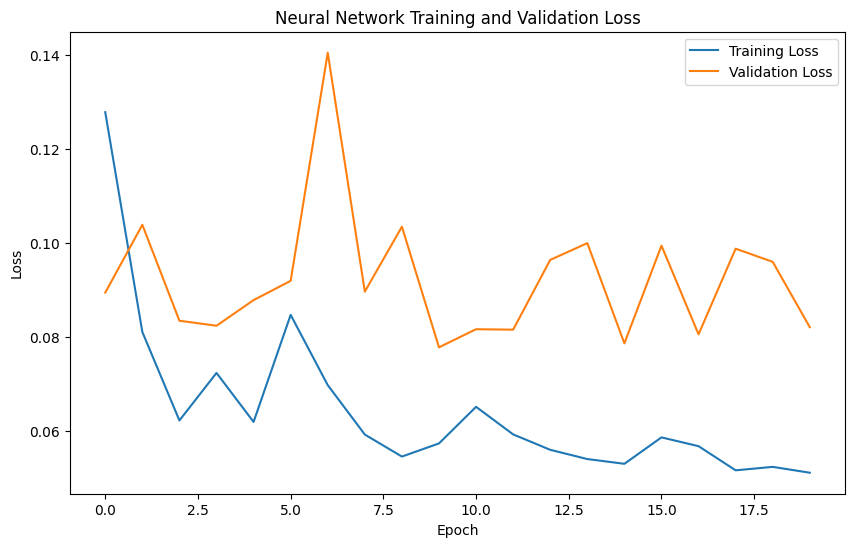

In [141]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Neural Network Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

The training and validation loss curves show how the neural network learned over time. A decreasing training loss indicates that the model was learning from the training data. The validation loss helps show whether the model generalizes well to unseen data.

In [142]:
# Make neural network predictions
nn_predictions_scaled = nn_model.predict(X_test_nn)

nn_predictions = target_scaler.inverse_transform(nn_predictions_scaled).flatten()

nn_predictions[:10]

131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([ 1959.1501,  2160.6956,  7349.3193, 27764.158 ,  1826.3762,
        2388.9258,  4170.6895,  2182.571 ,  2083.6616,  3738.2036],
      dtype=float32)

In [143]:
# Evaluate the neural network
nn_mae = mean_absolute_error(y_test, nn_predictions)
nn_rmse = np.sqrt(mean_squared_error(y_test, nn_predictions))
nn_r2 = r2_score(y_test, nn_predictions)

print("Neural Network MAE:", nn_mae)
print("Neural Network RMSE:", nn_rmse)
print("Neural Network R2:", nn_r2)

Neural Network MAE: 668.9847837820453
Neural Network RMSE: 1773.9547366129523
Neural Network R2: 0.8859365255354053



Three models were compared: a baseline model, a Random Forest Regressor, and a Neural Network.

The Random Forest model performed best overall. It had the lowest MAE, lowest RMSE, and highest R² score. This means it made smaller prediction errors and explained more variation in next month retail food prices than the other models.

The baseline model performed reasonably well because food prices usually do not change drastically from one month to the next. However, the Random Forest still improved on the baseline, showing that market, commodity, location, seasonality, and historical price features add useful predictive information.

The Neural Network performed better than the baseline in terms of RMSE and R², but it had a higher MAE than both the baseline and Random Forest. This suggests that the neural network captured some general price patterns but was less consistent in making small accurate predictions.

Based on these results, the Random Forest model is the best selection for this.

In [144]:
# Compare all models
final_model_comparison = pd.DataFrame({
    "Model": ["Baseline", "Random Forest", "Neural Network"],
    "MAE": [baseline_mae, rf_mae, nn_mae],
    "RMSE": [baseline_rmse, rf_rmse, nn_rmse],
    "R2": [baseline_r2, rf_r2, nn_r2]
})

final_model_comparison

,Model,MAE,RMSE,R2
0,Baseline,557.697085,1975.416296,0.858558
1,Random Forest,533.196833,1697.697237,0.895532
2,Neural Network,668.984784,1773.954737,0.885937


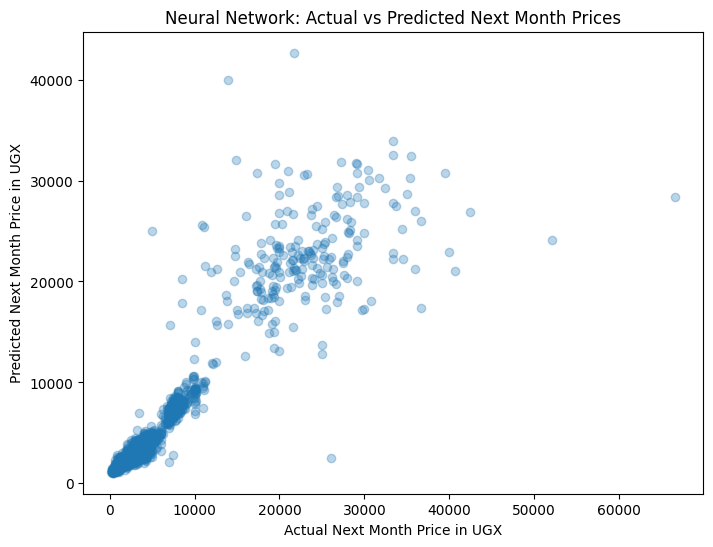

In [145]:
# Visualize actual vs predicted for neural network
plt.figure(figsize=(8, 6))
plt.scatter(y_test, nn_predictions, alpha=0.3)
plt.title("Neural Network: Actual vs Predicted Next Month Prices")
plt.xlabel("Actual Next Month Price in UGX")
plt.ylabel("Predicted Next Month Price in UGX")
plt.show()

# Summary: Neural Network Model

In this step, a neural network regression model was trained to predict next month retail food prices.

The model used the same processed features as the Random Forest model. The input features included time variables, location variables, commodity information, current price, previous price, price changes and moving averages.

The target variable was scaled before training because neural networks generally perform better when numerical values are standardized.

The neural network was evaluated using MAE, RMSE and R², and its performance was compared with both the baseline model and the Random Forest model.

# Model evaluation and saving

In [146]:
# Select the final model
final_model = rf_model
final_predictions = rf_predictions

print("Selected final model: Random Forest Regressor")

Selected final model: Random Forest Regressor


In [147]:
#create the final results table
final_results_df = X_test.copy()

final_results_df["actual_next_month_price"] = y_test
final_results_df["predicted_next_month_price"] = final_predictions
final_results_df["prediction_error"] = (
    final_results_df["actual_next_month_price"] 
    - final_results_df["predicted_next_month_price"]
)

final_results_df.head()

,year,month,quarter,admin1,admin2,market,latitude,longitude,category,commodity,unit,price,previous_price,price_change,price_pct_change,price_3_month_avg,price_6_month_avg,actual_next_month_price,predicted_next_month_price,prediction_error
18960,2024,12,4,Kyegegwa,Kyaka,Kyaka II (refugee settlement),0.36,31.09,milk and dairy,Milk (fresh),L,1500.0,1257.0,243.0,0.193317,1341.333333,1299.333333,1733.0,1423.362163,309.637837
19660,2024,12,4,Kyegegwa,Kyaka,Kyaka II (refugee settlement),0.36,31.09,vegetables and fruits,Leafy vegetables,KG,2000.0,1349.0,651.0,0.482580,1592.666667,1490.500000,2000.0,1363.470529,636.529471
14533,2024,12,4,Lira,Lira Municipality,Lira,2.23,32.91,oil and fats,Oil (vegetable),L,7500.0,7500.0,0.0,0.000000,7500.000000,7500.000000,6688.0,7506.224890,-818.224890
16983,2024,12,4,Kamwenge,Kibale,Rwamwanja (refugee settlement),0.31,30.68,"meat, fish and eggs",Fish (dry),KG,27328.0,27553.0,-225.0,-0.008166,27328.000000,27090.000000,33333.0,27411.580000,5921.420000
4057,2024,12,4,Soroti,Soroti Municipality,Soroti,1.71,33.62,cereals and tubers,Sorghum,KG,1300.0,1003.0,297.0,0.296112,1127.666667,1028.833333,1267.0,1396.704225,-129.704225


In [148]:
#check best and worst predictions
final_results_df["absolute_error"] = final_results_df["prediction_error"].abs()

final_results_df.sort_values("absolute_error").head(10)[[
    "year",
    "month",
    "market",
    "commodity",
    "price",
    "actual_next_month_price",
    "predicted_next_month_price",
    "absolute_error"
]]

,year,month,market,commodity,price,actual_next_month_price,predicted_next_month_price,absolute_error
12748,2025,1,Moroto,Maize flour,2000.0,2000.0,1999.975414,0.024586
18123,2026,2,Adjumani (refugee settlement),Salt,2056.0,2033.0,2033.064429,0.064429
9101,2025,2,Soroti,Millet,2880.0,2920.0,2919.843315,0.156685
17818,2026,2,Oruchinga (refugee settlement),Salt,1725.0,1863.0,1862.729645,0.270355
2231,2025,6,Nakivale (refugee settlement),Beans,2964.0,3034.0,3033.672064,0.327936
2590,2025,9,Napak,Beans,4000.0,4000.0,3999.610868,0.389132
2300,2026,2,Kyangwali (refugee settlement),Beans,2109.0,2198.0,2198.408263,0.408263
4212,2025,11,Arua,Sorghum,2600.0,2133.0,2133.467195,0.467195
4358,2025,1,Fort Portal,Sorghum,3000.0,3000.0,3000.470480,0.470480
18833,2026,5,Bidibidi (refugee settlement),Milk (fresh),1750.0,1750.0,1750.667984,0.667984


In [149]:
# Largest errors
final_results_df.sort_values("absolute_error", ascending=False).head(10)[[
    "year",
    "month",
    "market",
    "commodity",
    "price",
    "actual_next_month_price",
    "predicted_next_month_price",
    "absolute_error"
]]



,year,month,market,commodity,price,actual_next_month_price,predicted_next_month_price,absolute_error
16768,2025,3,Palabek (refugee settlement),Fish (dry),40701.0,66608.0,34071.580000,32536.420000
16782,2026,5,Palabek (refugee settlement),Fish (dry),27930.0,52169.0,22707.131875,29461.868125
19563,2026,4,Palorinya (refugee settlement),Leafy vegetables,2429.0,26111.0,2031.481465,24079.518535
17042,2025,2,Oruchinga (refugee settlement),Fish (dry),25416.0,5000.0,26498.615208,21498.615208
16933,2025,3,Kiryandongo (refugee settlement),Fish (dry),42500.0,14886.0,36110.440000,21224.440000
16992,2025,9,Rwamwanja (refugee settlement),Fish (dry),13815.0,36667.0,15646.330000,21020.670000
17210,2025,3,Rhino Camp (refugee settlement),Fish (dry),25833.0,40000.0,21485.904167,18514.095833
16767,2025,2,Palabek (refugee settlement),Fish (dry),22372.0,40701.0,22796.200000,17904.800000
17049,2025,9,Oruchinga (refugee settlement),Fish (dry),21630.0,8571.0,25729.410000,17158.410000
17043,2025,3,Oruchinga (refugee settlement),Fish (dry),5000.0,8571.0,25569.800000,16998.800000


The largest prediction errors mostly occur where there are sudden price changes or unusually high food prices. This is expected because food prices can be affected by market shocks, seasonality, transport costs, supply shortages, inflation, and other external factors that are not fully captured in the dataset.

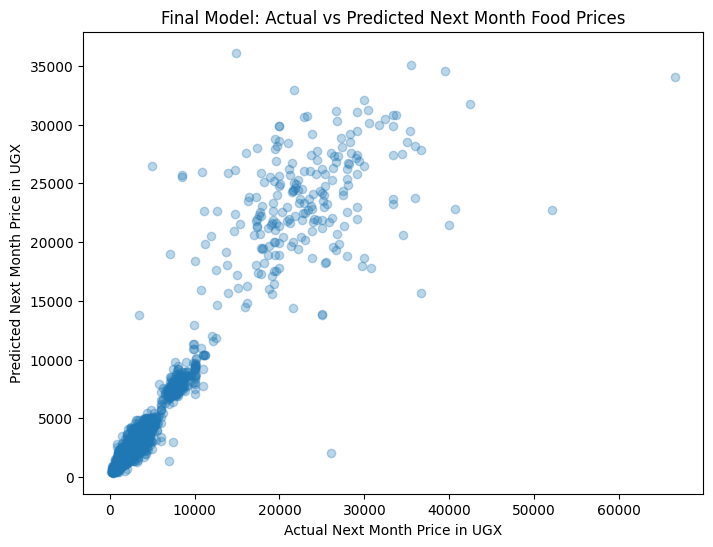

In [150]:
#Plot actual vs predicted prices for the final model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, final_predictions, alpha=0.3)
plt.title("Final Model: Actual vs Predicted Next Month Food Prices")
plt.xlabel("Actual Next Month Price in UGX")
plt.ylabel("Predicted Next Month Price in UGX")
plt.show()

The actual vs predicted plot shows that many predictions are close to the actual values. This indicates that the model learned useful patterns from the data. However, some points are far from the main pattern, showing that the model struggles with sudden price spikes and extreme values.

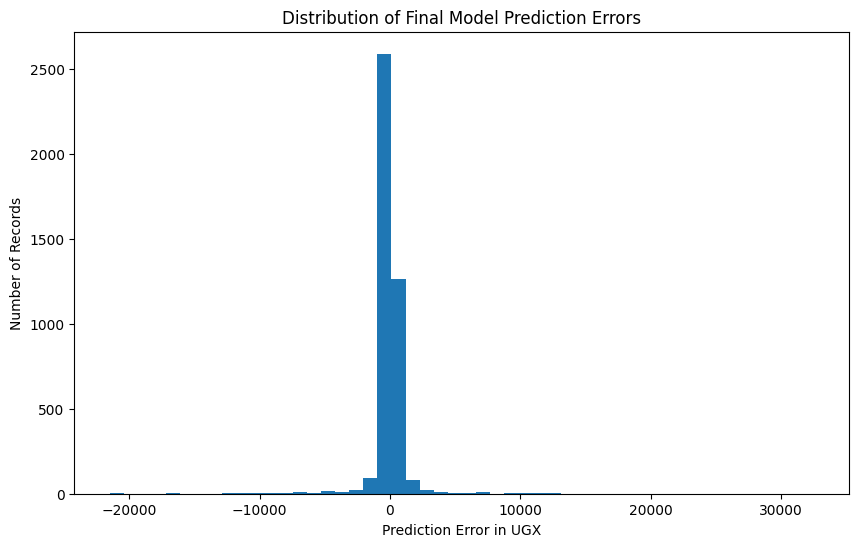

In [151]:
#Plot prediction error distribution
plt.figure(figsize=(10, 6))
plt.hist(final_results_df["prediction_error"], bins=50)
plt.title("Distribution of Final Model Prediction Errors")
plt.xlabel("Prediction Error in UGX")
plt.ylabel("Number of Records")
plt.show()

The error distribution shows that most prediction errors are concentrated around zero, which means the model generally predicts close to the actual next month price. Larger errors are less frequent and may be linked to sudden market price changes or outliers.

In [152]:
# Feature importance: To see which features helped the Random Forest most.
# Get feature names after preprocessing
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

# Get Random Forest feature importances
importances = final_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
10,num__price_6_month_avg,0.423630
9,num__price_3_month_avg,0.420128
5,num__price,0.125450
8,num__price_pct_change,0.004348
1,num__month,0.004057
6,num__previous_price,0.003965
7,num__price_change,0.003315
0,num__year,0.002676
3,num__latitude,0.002585
4,num__longitude,0.001900


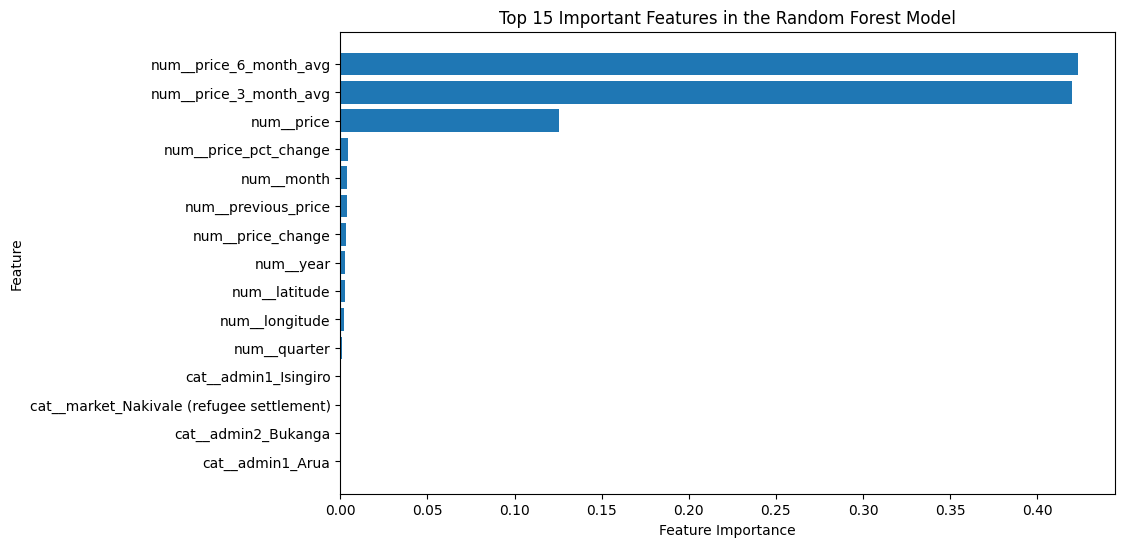

In [153]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Important Features in the Random Forest Model")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

The feature importance results show which variables contributed most to the model's predictions. Historical price variables such as current price, previous price and moving averages are expected to be among the strongest predictors because food prices tend to follow recent price trends.

In [154]:
#save final predictions
final_results_df.to_csv("/content/final_food_price_predictions.csv", index=False)

In [155]:
#download
from google.colab import files

files.download("final_food_price_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [156]:
#save the final modal
import joblib

joblib.dump(final_model, "/content/random_forest_food_price_model.pkl")

['/content/random_forest_food_price_model.pkl']

In [157]:
files.download("random_forest_food_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary

The Random Forest Regressor was selected as the final model because it achieved the best performance among the tested models.

The final model achieved:
- MAE: 533.20
- RMSE: 1697.70
- R²: 0.8955

This means that the model explains approximately 89.6% of the variation in next month retail food prices. The final model was saved for use in the project demo/interface.

In [158]:
reference_columns = features + ["date"]

app_reference_df = ml_df[reference_columns].copy()

app_reference_df.to_csv("food_price_input_reference.csv", index=False)

In [159]:
# checking whether these were generated and saved.
import os

os.path.exists("food_price_input_reference.csv")

True

In [160]:
os.path.exists("random_forest_food_price_model.pkl")

True

In [161]:
!pip install gradio -q

In [162]:
import gradio as gr
import pandas as pd
import numpy as np
import joblib

In [163]:
print(os.path.exists("random_forest_food_price_model.pkl"))
print(os.path.exists("food_price_input_reference.csv"))

True
True


In [165]:
reference_columns = features + ["date"]

app_reference_df = ml_df[reference_columns].copy()

app_reference_df.to_csv("/content/food_price_input_reference.csv", index=False)

In [166]:
joblib.dump(final_model, "random_forest_food_price_model.pkl")


['random_forest_food_price_model.pkl']

In [167]:
model = joblib.load("random_forest_food_price_model.pkl")

ref_df = pd.read_csv("food_price_input_reference.csv")
ref_df["date"] = pd.to_datetime(ref_df["date"])

ref_df.head()


,year,month,quarter,admin1,admin2,market,latitude,longitude,category,commodity,unit,price,previous_price,price_change,price_pct_change,price_3_month_avg,price_6_month_avg,date
0,2008,12,4,Kampala,Central Kampala,Owino,0.32,32.57,vegetables and fruits,Plantains,KG,412.50,407.27,5.23,0.012842,414.923333,362.021667,2008-12-15
1,2008,12,4,Kampala,Central Kampala,Owino,0.32,32.57,cereals and tubers,Cassava flour,KG,775.00,787.50,-12.50,-0.015873,757.500000,738.720000,2008-12-15
2,2009,1,1,Kampala,Central Kampala,Owino,0.32,32.57,cereals and tubers,Cassava flour,KG,776.92,775.00,1.92,0.002477,779.806667,751.540000,2009-01-15
3,2009,1,1,Kampala,Central Kampala,Owino,0.32,32.57,vegetables and fruits,Plantains,KG,395.00,412.50,-17.50,-0.042424,404.923333,383.480000,2009-01-15
4,2009,2,1,Kampala,Central Kampala,Owino,0.32,32.57,vegetables and fruits,Plantains,KG,386.00,395.00,-9.00,-0.022785,397.833333,396.146667,2009-02-15


In [168]:
commodities = sorted(ref_df["commodity"].unique())
markets = sorted(ref_df["market"].unique())

print("Number of commodities:", len(commodities))
print("Number of markets:", len(markets))

Number of commodities: 15
Number of markets: 42


In [169]:
#create the prediction functin
def predict_food_price(commodity, market, current_price, previous_price, price_3_month_avg, price_6_month_avg):
    # Filter data for selected commodity and market
    filtered_df = ref_df[
        (ref_df["commodity"] == commodity) &
        (ref_df["market"] == market)
    ].copy()
    
    if filtered_df.empty:
        return "No historical data found for this commodity and market combination."
    
    # Get latest available record
    latest_record = filtered_df.sort_values("date").iloc[-1]
    
    # Calculate price change features
    price_change = current_price - previous_price
    
    if previous_price == 0:
        price_pct_change = 0
    else:
        price_pct_change = price_change / previous_price
    
    # Create input dataframe
    input_data = pd.DataFrame([{
        "year": int(latest_record["year"]),
        "month": int(latest_record["month"]),
        "quarter": int(latest_record["quarter"]),
        "admin1": latest_record["admin1"],
        "admin2": latest_record["admin2"],
        "market": latest_record["market"],
        "latitude": float(latest_record["latitude"]),
        "longitude": float(latest_record["longitude"]),
        "category": latest_record["category"],
        "commodity": latest_record["commodity"],
        "unit": latest_record["unit"],
        "price": current_price,
        "previous_price": previous_price,
        "price_change": price_change,
        "price_pct_change": price_pct_change,
        "price_3_month_avg": price_3_month_avg,
        "price_6_month_avg": price_6_month_avg
    }])
    
    prediction = model.predict(input_data)[0]
    
    difference = prediction - current_price
    
    if difference > 0:
        direction = f"The model predicts a price increase of UGX {difference:,.0f}."
    elif difference < 0:
        direction = f"The model predicts a price decrease of UGX {abs(difference):,.0f}."
    else:
        direction = "The model predicts no price change."
    
    return (
        f"Predicted next month retail price: UGX {prediction:,.0f}\n\n"
        f"Commodity: {commodity}\n"
        f"Market: {market}\n"
        f"Current price: UGX {current_price:,.0f}\n"
        f"{direction}"
    )

In [170]:
# build the gradio app
demo = gr.Interface(
    fn=predict_food_price,
    inputs=[
        gr.Dropdown(choices=commodities, label="Commodity"),
        gr.Dropdown(choices=markets, label="Market"),
        gr.Number(label="Current Retail Price (UGX)", value=3000),
        gr.Number(label="Previous Price (UGX)", value=2800),
        gr.Number(label="3-Month Average Price (UGX)", value=2900),
        gr.Number(label="6-Month Average Price (UGX)", value=2850)
    ],
    outputs=gr.Textbox(label="Prediction Result"),
    title="Uganda Retail Food Price Prediction App",
    description=(
        "This demo predicts the next month retail food price for a selected "
        "commodity and market in Uganda using a trained Random Forest regression model."
    )
)

In [172]:
#launch the app
demo.launch(share=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://56e56df561f7cb4d55.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Step 8 Summary: Demo Interface

A Gradio demo interface was created for the final Random Forest regression model. The interface allows a user to select a food commodity and market, enter current and historical price values, and predict the next month retail food price.

Gradio was used instead of Streamlit because it works more reliably in Google Colab and provides a shareable link for demonstration.